# BEAD Random Forest Model
Predicts `funding_per_location` (raw $, no log transform) using 8 features from the BEAD Summary Paper.

In [23]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project="broadband-data")
print("Connected to BigQuery: broadband-data")

Connected to BigQuery: broadband-data


In [25]:
# Load project-level data from fp_approved.deployment_projects
project_query = """
SELECT
    project_id,
    state,
    bead_support,
    estimated_miles_aerial_fiber,
    estimated_miles_buried_fiber,
    estimated_jobs,
    project_type,
    priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
"""
df_projects = client.query(project_query).to_dataframe()
print(f"Projects: {df_projects.shape}")
df_projects.head()

Projects: (5251, 8)


,project_id,state,bead_support,estimated_miles_aerial_fiber,estimated_miles_buried_fiber,estimated_jobs,project_type,priority_broadband_project
0,CM61-BEAD-ID-007067,ID,4019796.00,16.0,42.0,20,L,True
1,CM61-BEAD-ID-007072,ID,10641940.00,0.0,97.0,2,L,True
2,CM61-BEAD-ID-007074,ID,162966.50,0.0,8.0,0,L,True
3,CM61-BEAD-ID-007075,ID,1811284.58,20.0,5.0,12,L,True
4,CM61-BEAD-ID-007078,ID,107623.48,0.0,0.0,0,L,True


In [26]:
# Aggregate fp_approved.locations to project level
location_query = """
SELECT
    project_id,
    COUNT(*) AS funded_locations,
    SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value AS FLOAT64) AS technology,
    AVG(CAST(low_latency AS INT64)) AS avg_latency
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
"""
df_locations = client.query(location_query).to_dataframe()
print(f"Location aggregates: {df_locations.shape}")
df_locations.head()

Location aggregates: (5228, 4)


,project_id,funded_locations,technology,avg_latency
0,CM61-BEAD-VT-83905,7441,50.0,1.0
1,CM61-BEAD-VT-85073,184,50.0,1.0
2,CM61-BEAD-VT-85559,66,40.0,1.0
3,CM61-BEAD-VT-85560,65,50.0,1.0
4,CM61-BEAD-VT-85803,18,61.0,1.0


In [27]:
# state_num_providers from FCC NBM
# NBM uses full state names — map to 2-letter abbreviations to match project_clean
state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}

nbm_query = """
SELECT
    state,
    COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fcc_nbm.nbm_hive`
GROUP BY state
"""
df_nbm = client.query(nbm_query).to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])
print(f"State provider counts: {df_nbm.shape}")
df_nbm.head()

State provider counts: (51, 2)


,state,state_num_providers
0,SD,79
1,ID,93
2,MS,100
3,TN,151
4,AR,138


In [ ]:
# State population from Census block-level data (2020)
state_pop_query = """
SELECT 
    stateabbr AS state,
    SUM(pop2020) AS state_population
FROM `broadband-data.fcc_block_level_pop.us2020`
GROUP BY stateabbr
"""
df_state_pop = client.query(state_pop_query).to_dataframe()
print(f"State population data: {df_state_pop.shape}")
print(df_state_pop.sort_values('state_population', ascending=False).head(10))

In [ ]:
# Incumbent governor party by state (as of 2024, when BEAD proposals were submitted)
# D=Democrat, R=Republican — encoded as binary: 1=Democrat, 0=Republican
governor_party_2024 = {
    'AL': 0, 'AK': 0, 'AZ': 1, 'AR': 0, 'CA': 1,
    'CO': 1, 'CT': 1, 'DE': 1, 'FL': 0, 'GA': 0,
    'HI': 1, 'ID': 0, 'IL': 1, 'IN': 0, 'IA': 0,
    'KS': 1, 'KY': 1, 'LA': 0, 'ME': 1, 'MD': 1,
    'MA': 1, 'MI': 1, 'MN': 1, 'MS': 0, 'MO': 0,
    'MT': 0, 'NE': 0, 'NV': 0, 'NH': 0, 'NJ': 1,
    'NM': 1, 'NY': 1, 'NC': 1, 'ND': 0, 'OH': 0,
    'OK': 0, 'OR': 1, 'PA': 1, 'RI': 1, 'SC': 0,
    'SD': 0, 'TN': 0, 'TX': 0, 'UT': 0, 'VT': 0,
    'VA': 0, 'WA': 1, 'WV': 0, 'WI': 1, 'WY': 0,
    'DC': 1
}
df_gov = pd.DataFrame(list(governor_party_2024.items()), columns=['state', 'incumbent_democrat'])
print(f"Governor party: D={df_gov['incumbent_democrat'].sum()}, R={(df_gov['incumbent_democrat']==0).sum()}")

In [ ]:
# Merge all sources
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')
df = df.merge(df_state_pop, on='state', how='left')
df = df.merge(df_gov, on='state', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology'] = df['technology'].fillna(0)
df['avg_latency'] = df['avg_latency'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population'] = df['state_population'].fillna(0)
df['incumbent_democrat'] = df['incumbent_democrat'].fillna(0).astype(int)

print(f"Merged shape: {df.shape}")
df.head()

## Exploratory Data Analysis — Feature Cleaning & Inspection

=== Dominant Technology ===
Unique values: [np.float64(0.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(61.0), np.float64(70.0), np.float64(71.0), np.float64(72.0)]

Value counts:
technology
0.0       30
40.0      73
50.0    2657
60.0       2
61.0    1839
70.0      30
71.0     472
72.0     148
Name: count, dtype: int64

Missing/zero: 30 (0.6%)

⚠️  1841 rows with unexpected technology codes: [61. 60.]


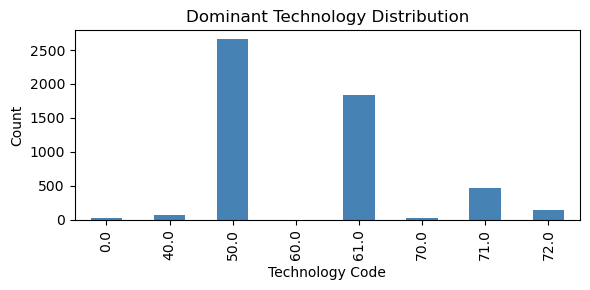

In [29]:
# --- 1. Dominant Technology ---
# 50 = Fiber, 40 = Cable, 70 = Wireless
print("=== Dominant Technology ===")
print(f"Unique values: {sorted(df['technology'].unique())}")
print(f"\nValue counts:\n{df['technology'].value_counts().sort_index()}")
print(f"\nMissing/zero: {(df['technology'] == 0).sum()} ({(df['technology'] == 0).mean()*100:.1f}%)")

# Flag unexpected codes (not 50, 40, 70, or 0)
expected_tech = {0, 40, 50, 70, 71, 72}
unexpected = df[~df['technology'].isin(expected_tech)]
if len(unexpected) > 0:
    print(f"\n⚠️  {len(unexpected)} rows with unexpected technology codes: {unexpected['technology'].unique()}")
else:
    print("\n✓ All technology values are expected codes")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df['technology'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_title('Dominant Technology Distribution')
ax.set_xlabel('Technology Code')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

=== Avg Latency ===
count    5251.000000
mean        0.842506
std         0.364300
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: avg_latency, dtype: float64

Exact zeros: 827 (15.7%)
Exact ones:  4424 (84.3%)
Between 0 and 1: 0

✓ All avg_latency values in [0, 1]


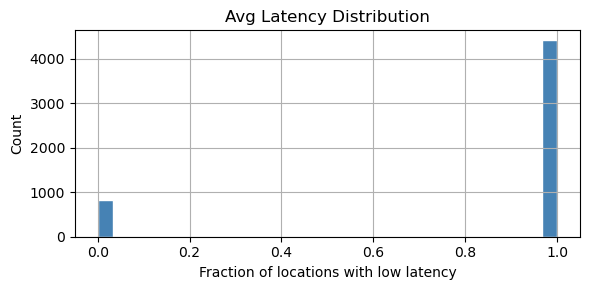

In [30]:
# --- 2. Avg Latency (fraction of locations with low latency service) ---
print("=== Avg Latency ===")
print(df['avg_latency'].describe())
print(f"\nExact zeros: {(df['avg_latency'] == 0).sum()} ({(df['avg_latency'] == 0).mean()*100:.1f}%)")
print(f"Exact ones:  {(df['avg_latency'] == 1).sum()} ({(df['avg_latency'] == 1).mean()*100:.1f}%)")
print(f"Between 0 and 1: {((df['avg_latency'] > 0) & (df['avg_latency'] < 1)).sum()}")

# Check for values outside [0, 1]
out_of_range = df[(df['avg_latency'] < 0) | (df['avg_latency'] > 1)]
if len(out_of_range) > 0:
    print(f"\n⚠️  {len(out_of_range)} rows with avg_latency outside [0,1]: {out_of_range['avg_latency'].describe()}")
else:
    print("\n✓ All avg_latency values in [0, 1]")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df['avg_latency'].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Avg Latency Distribution')
ax.set_xlabel('Fraction of locations with low latency')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

=== Total Fiber Miles ===
count     5251.000000
mean        83.500020
std        381.818791
min          0.000000
25%          0.000000
50%          2.000000
75%         67.880000
max      19673.000000
Name: total_fiber_miles, dtype: float64

Zero fiber miles: 2515 (47.9%)
Negative values: 0

Aerial only:  218
Buried only:  1057
Both:         1461
Neither:      2515


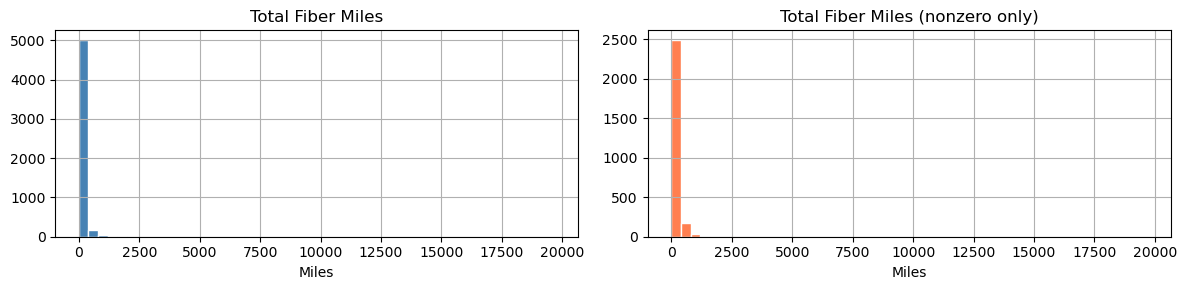

In [31]:
# --- 3. Total Fiber Miles (aerial + buried) ---
df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)

print("=== Total Fiber Miles ===")
print(df['total_fiber_miles'].describe())
print(f"\nZero fiber miles: {(df['total_fiber_miles'] == 0).sum()} ({(df['total_fiber_miles'] == 0).mean()*100:.1f}%)")
print(f"Negative values: {(df['total_fiber_miles'] < 0).sum()}")

# Check aerial vs buried breakdown
print(f"\nAerial only:  {((df['estimated_miles_aerial_fiber'] > 0) & (df['estimated_miles_buried_fiber'] == 0)).sum()}")
print(f"Buried only:  {((df['estimated_miles_aerial_fiber'] == 0) & (df['estimated_miles_buried_fiber'] > 0)).sum()}")
print(f"Both:         {((df['estimated_miles_aerial_fiber'] > 0) & (df['estimated_miles_buried_fiber'] > 0)).sum()}")
print(f"Neither:      {((df['estimated_miles_aerial_fiber'] == 0) & (df['estimated_miles_buried_fiber'] == 0)).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
df['total_fiber_miles'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Fiber Miles')
axes[0].set_xlabel('Miles')

# Log scale for better visibility of spread
df['total_fiber_miles'][df['total_fiber_miles'] > 0].hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Total Fiber Miles (nonzero only)')
axes[1].set_xlabel('Miles')
plt.tight_layout()
plt.show()

=== Miles Per Location ===
count       5251.0
mean      0.346543
std      11.111958
min            0.0
25%            0.0
50%       0.024064
75%       0.170213
max         786.92
Name: miles_per_location, dtype: Float64

Zero: 2531 (48.2%)
Negative: 0

99th percentile: 1.67
Projects above 99th: 52


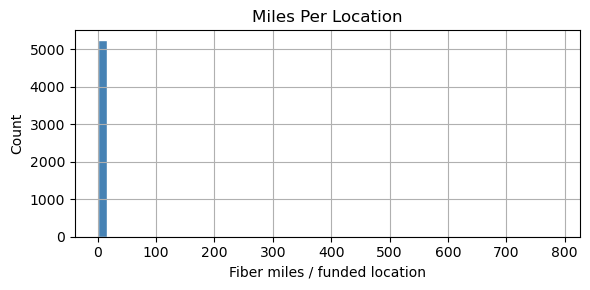

In [32]:
# --- 4. Miles Per Location (total fiber miles / funded locations) ---
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)

print("=== Miles Per Location ===")
print(df['miles_per_location'].describe())
print(f"\nZero: {(df['miles_per_location'] == 0).sum()} ({(df['miles_per_location'] == 0).mean()*100:.1f}%)")
print(f"Negative: {(df['miles_per_location'] < 0).sum()}")

# Outlier check
p99 = df['miles_per_location'].quantile(0.99)
print(f"\n99th percentile: {p99:.2f}")
print(f"Projects above 99th: {(df['miles_per_location'] > p99).sum()}")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df['miles_per_location'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Miles Per Location')
ax.set_xlabel('Fiber miles / funded location')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

=== Jobs Per Location ===
count      5251.0
mean     0.087838
std      0.727911
min           0.0
25%           0.0
50%           0.0
75%      0.017498
max          20.0
Name: jobs_per_location, dtype: Float64

Zero: 2830 (53.9%)
Negative: 0

99th percentile: 1.41
Projects above 99th pctl (53):
              project_id  estimated_jobs  funded_locations  jobs_per_location
165  CM61-BEAD-IA-629119               6                 4                1.5
285  CM61-BEAD-MA-NE4COM             335               126            2.65873
390   CM61-BEAD-CT-003-1              14                 2                7.0
392   CM61-BEAD-CT-007-1              14                 1               14.0
394   CM61-BEAD-CT-013-1              14                 2                7.0


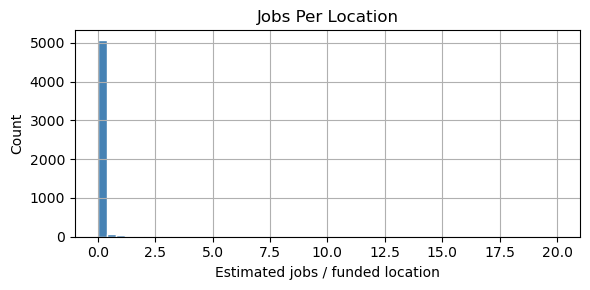

In [33]:
# --- 5. Jobs Per Location ---
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)

print("=== Jobs Per Location ===")
print(df['jobs_per_location'].describe())
print(f"\nZero: {(df['jobs_per_location'] == 0).sum()} ({(df['jobs_per_location'] == 0).mean()*100:.1f}%)")
print(f"Negative: {(df['jobs_per_location'] < 0).sum()}")

# Check for suspiciously high values
p99 = df['jobs_per_location'].quantile(0.99)
print(f"\n99th percentile: {p99:.2f}")
high_jpl = df[df['jobs_per_location'] > p99]
if len(high_jpl) > 0:
    print(f"Projects above 99th pctl ({len(high_jpl)}):")
    print(high_jpl[['project_id', 'estimated_jobs', 'funded_locations', 'jobs_per_location']].head())

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df['jobs_per_location'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Jobs Per Location')
ax.set_xlabel('Estimated jobs / funded location')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

=== Priority Broadband Project ===
Raw unique values: <BooleanArray>
[True, False]
Length: 2, dtype: boolean
Raw dtype: boolean

After cleaning:
priority_broadband_project
1    4011
0    1240
Name: count, dtype: int64

Missing: 0


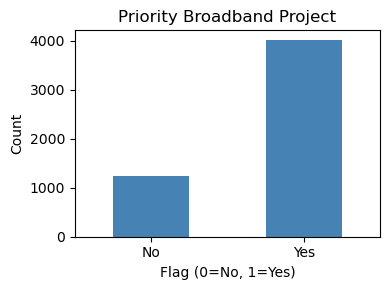

In [34]:
# --- 6. Priority Broadband Project (binary) ---
print("=== Priority Broadband Project ===")
print(f"Raw unique values: {df['priority_broadband_project'].unique()}")
print(f"Raw dtype: {df['priority_broadband_project'].dtype}")

# Clean to binary
df['priority_broadband_project'] = (
    df['priority_broadband_project']
    .map({True: 1, False: 0, 'Yes': 1, 'No': 0, 1: 1, 0: 0})
    .fillna(0).astype(int)
)
print(f"\nAfter cleaning:")
print(df['priority_broadband_project'].value_counts())
print(f"\nMissing: {df['priority_broadband_project'].isna().sum()}")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
df['priority_broadband_project'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_title('Priority Broadband Project')
ax.set_xlabel('Flag (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

=== Project Type ===
Unique values: ['L' 'C' None]

Value counts:
project_type
L    5088
C      13
Name: count, dtype: int64

Missing: 150

Mapping:
  0 = C
  1 = L


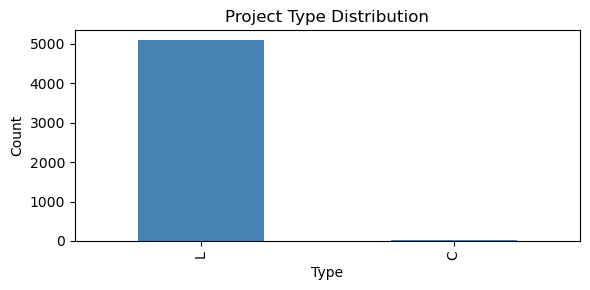

In [35]:
# --- 7. Project Type ---
print("=== Project Type ===")
print(f"Unique values: {df['project_type'].unique()}")
print(f"\nValue counts:\n{df['project_type'].value_counts()}")
print(f"\nMissing: {df['project_type'].isna().sum()}")

df['project_type_code'] = df['project_type'].astype('category').cat.codes
print(f"\nMapping:")
for code, ptype in enumerate(df['project_type'].astype('category').cat.categories):
    print(f"  {code} = {ptype}")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df['project_type'].value_counts().plot.bar(ax=ax, color='steelblue')
ax.set_title('Project Type Distribution')
ax.set_xlabel('Type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

=== State Number of Providers ===
count        5251.0
mean     160.895068
std       89.391304
min            17.0
25%           126.0
50%           156.0
75%           163.0
max           618.0
Name: state_num_providers, dtype: Float64

Zero/missing: 0 (0.0%)
Unique states in data: 46
States with provider data: 46

✓ All states have provider counts


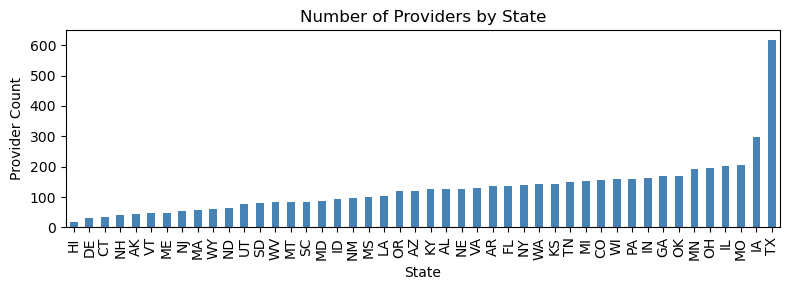

In [36]:
# --- 8. State Number of Providers ---
print("=== State Number of Providers ===")
print(df['state_num_providers'].describe())
print(f"\nZero/missing: {(df['state_num_providers'] == 0).sum()} ({(df['state_num_providers'] == 0).mean()*100:.1f}%)")
print(f"Unique states in data: {df['state'].nunique()}")
print(f"States with provider data: {df[df['state_num_providers'] > 0]['state'].nunique()}")

# Check for states that didn't get provider counts
states_missing = df[df['state_num_providers'] == 0]['state'].unique()
if len(states_missing) > 0:
    print(f"\n⚠️  States missing provider data: {states_missing}")
else:
    print("\n✓ All states have provider counts")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
state_providers = df.groupby('state')['state_num_providers'].first().sort_values()
state_providers.plot.bar(ax=ax, color='steelblue')
ax.set_title('Number of Providers by State')
ax.set_xlabel('State')
ax.set_ylabel('Provider Count')
plt.tight_layout()
plt.show()

In [37]:
# --- Feature Correlation & Summary ---
feature_cols_eda = ['technology', 'avg_latency', 'total_fiber_miles', 'miles_per_location',
                    'jobs_per_location', 'priority_broadband_project', 'project_type_code', 'state_num_providers']

print("=== Pairwise Correlation Matrix ===")
corr = df[feature_cols_eda].corr()
print(corr.round(2).to_string())

# Flag high correlations (>0.7)
print("\n=== High Correlations (|r| > 0.7) ===")
for i in range(len(feature_cols_eda)):
    for j in range(i+1, len(feature_cols_eda)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  ⚠️  {feature_cols_eda[i]} ↔ {feature_cols_eda[j]}: r={r:.3f}")

# Summary table
print("\n=== Feature Summary ===")
summary = df[feature_cols_eda].describe().T[['count', 'mean', 'std', 'min', 'max']]
summary['zeros'] = (df[feature_cols_eda] == 0).sum()
summary['missing'] = df[feature_cols_eda].isna().sum()
print(summary.to_string())

=== Pairwise Correlation Matrix ===
                            technology  avg_latency  total_fiber_miles  miles_per_location  jobs_per_location  priority_broadband_project  project_type_code  state_num_providers
technology                        1.00        -0.11              -0.14               -0.02               0.00                       -0.38               0.03                 0.00
avg_latency                      -0.11         1.00               0.06                0.01               0.05                       -0.08               0.41                -0.40
total_fiber_miles                -0.14         0.06               1.00                0.70              -0.02                        0.11              -0.02                 0.02
miles_per_location               -0.02         0.01               0.70                1.00               0.01                        0.02               0.00                -0.00
jobs_per_location                 0.00         0.05              -0.02    

In [38]:
# Target variable — raw funding per location (no log transform)
df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])

# Remove top/bottom 2.5% outliers (keep middle 95%)
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]
print(f"After outlier removal: {df.shape[0]} projects")
print(df['funding_per_location'].describe())

After outlier removal: 4885 projects
count          4885.0
mean      4007.728617
std        3663.46364
min        375.805556
25%            1500.0
50%       2279.638548
75%       6007.011444
max      15846.325167
Name: funding_per_location, dtype: Float64


In [39]:
# Final feature set — 8 features, no log transforms
feature_cols = [
    'technology',              # Dominant tech: 50=fiber, 40=cable, 70=wireless
    'avg_latency',             # Fraction of locations with low latency
    'total_fiber_miles',       # Aerial + buried fiber miles
    'miles_per_location',      # Fiber miles / funded locations (spread proxy)
    'jobs_per_location',       # Estimated jobs / funded locations
    'priority_broadband_project',  # Binary: NTIA priority designation
    'project_type_code',       # Project type (last mile, middle mile, etc.)
    'state_num_providers',     # Unique ISPs in state (competition proxy)
]

X = df[feature_cols].fillna(0)
y = df['funding_per_location']

print(f"Features: {len(feature_cols)} | Samples: {len(X)}")
print(feature_cols)

Features: 8 | Samples: 4885
['technology', 'avg_latency', 'total_fiber_miles', 'miles_per_location', 'jobs_per_location', 'priority_broadband_project', 'project_type_code', 'state_num_providers']


In [40]:
# Train Random Forest — predicting raw funding_per_location
from sklearn.model_selection import KFold

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
cv   = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=cv, scoring='r2')

print(f"Test R²:               {r2:.3f}")
print(f"Test RMSE ($):         {rmse:,.0f}")
print(f"Test MAE ($):          {mae:,.0f}")
print(f"5-fold CV R²:          {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

Test R²:               0.647
Test RMSE ($):         2,227
Test MAE ($):          1,361
5-fold CV R²:          0.639 ± 0.012


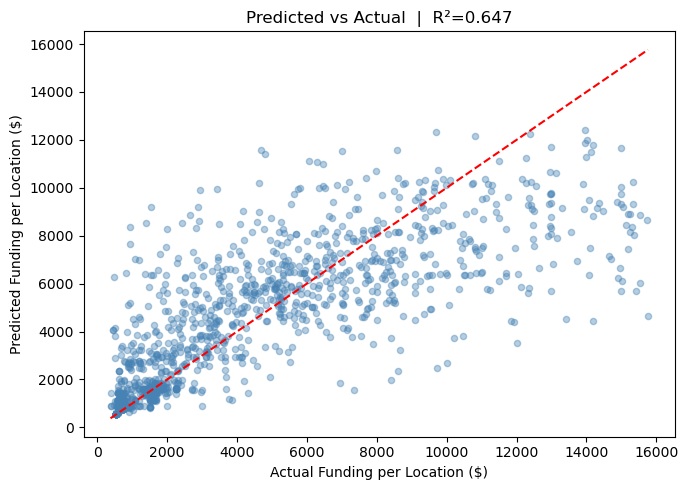

In [41]:
# Predicted vs Actual (raw $)
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual Funding per Location ($)')
ax.set_ylabel('Predicted Funding per Location ($)')
ax.set_title(f'Predicted vs Actual  |  R²={r2:.3f}')
plt.tight_layout()
plt.savefig('rf_predictions.png', dpi=150)
plt.show()

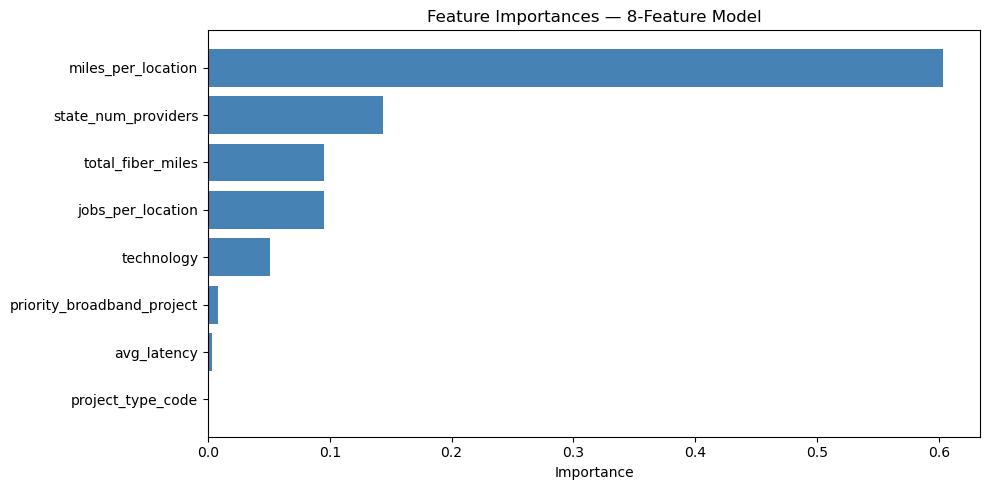

                   feature  importance
        miles_per_location    0.603700
       state_num_providers    0.143247
         total_fiber_miles    0.094914
         jobs_per_location    0.094876
                technology    0.051096
priority_broadband_project    0.008280
               avg_latency    0.002995
         project_type_code    0.000893


In [42]:
# Feature Importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importances — 8-Feature Model')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print(importance_df.to_string(index=False))

## Single-Feature Model: Miles Per Location Only

=== Single Feature: miles_per_location ===
Test R²:               0.365
Test RMSE ($):         2,986
Test MAE ($):          1,949
5-fold CV R²:          0.379 ± 0.021

--- Comparison to 8-feature model ---
8-feature R²: 0.647  |  Single-feature R²: 0.365  |  Drop: 0.282


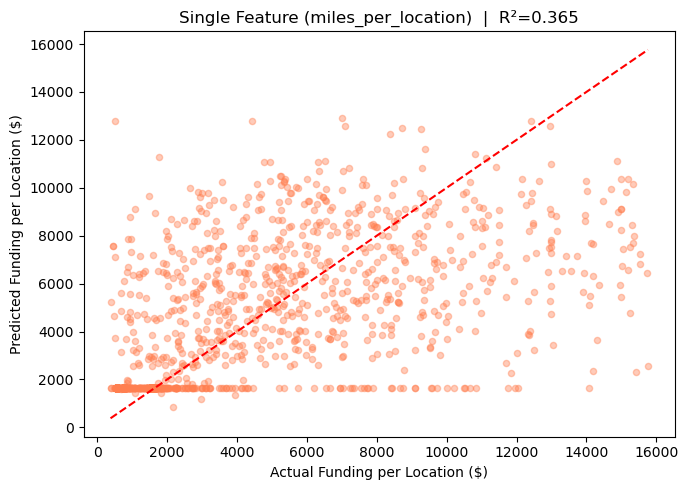

In [43]:
# Random Forest with miles_per_location only
X_single = df[['miles_per_location']].fillna(0)
y_single = df['funding_per_location']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_single, y_single, test_size=0.3, random_state=42)

rf_single = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf_single.fit(X_train_s, y_train_s)
y_pred_s = rf_single.predict(X_test_s)

r2_s   = r2_score(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
mae_s  = mean_absolute_error(y_test_s, y_pred_s)
cv_s   = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_s = cross_val_score(rf_single, X_single, y_single, cv=cv_s, scoring='r2')

print("=== Single Feature: miles_per_location ===")
print(f"Test R²:               {r2_s:.3f}")
print(f"Test RMSE ($):         {rmse_s:,.0f}")
print(f"Test MAE ($):          {mae_s:,.0f}")
print(f"5-fold CV R²:          {cv_r2_s.mean():.3f} ± {cv_r2_s.std():.3f}")

print(f"\n--- Comparison to 8-feature model ---")
print(f"8-feature R²: {r2:.3f}  |  Single-feature R²: {r2_s:.3f}  |  Drop: {r2 - r2_s:.3f}")

# Predicted vs Actual
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(y_test_s, y_pred_s, alpha=0.4, s=20, color='coral')
lims = [min(y_test_s.min(), y_pred_s.min()), max(y_test_s.max(), y_pred_s.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual Funding per Location ($)')
ax.set_ylabel('Predicted Funding per Location ($)')
ax.set_title(f'Single Feature (miles_per_location)  |  R²={r2_s:.3f}')
plt.tight_layout()
plt.show()

=== Two Features: miles_per_location + state_num_providers ===
Test R²:               0.560
Test RMSE ($):         2,484
Test MAE ($):          1,586
5-fold CV R²:          0.555 ± 0.010

--- Comparison ---
8-feature R²: 0.647  |  2-feature R²: 0.560  |  1-feature R²: 0.365

Feature importances:
  miles_per_location: 0.7942
  state_num_providers: 0.2058


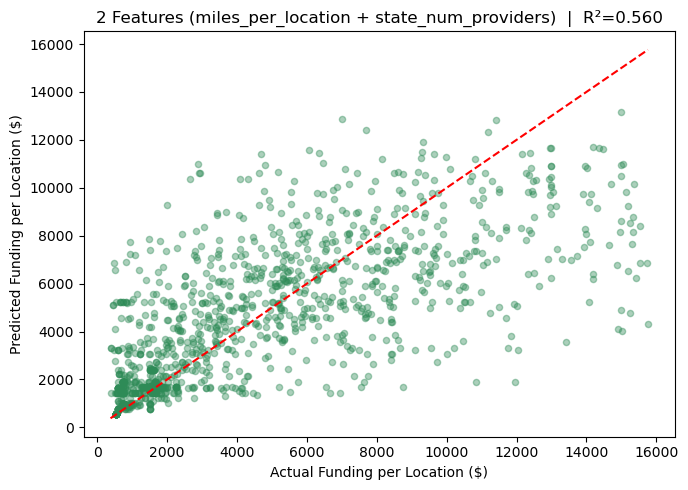

In [44]:
# Random Forest with miles_per_location + state_num_providers
X_two = df[['miles_per_location', 'state_num_providers']].fillna(0)
y_two = df['funding_per_location']

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_two, y_two, test_size=0.3, random_state=42)

rf_two = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf_two.fit(X_train_2, y_train_2)
y_pred_2 = rf_two.predict(X_test_2)

r2_2   = r2_score(y_test_2, y_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_2))
mae_2  = mean_absolute_error(y_test_2, y_pred_2)
cv_2   = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_2 = cross_val_score(rf_two, X_two, y_two, cv=cv_2, scoring='r2')

print("=== Two Features: miles_per_location + state_num_providers ===")
print(f"Test R²:               {r2_2:.3f}")
print(f"Test RMSE ($):         {rmse_2:,.0f}")
print(f"Test MAE ($):          {mae_2:,.0f}")
print(f"5-fold CV R²:          {cv_r2_2.mean():.3f} ± {cv_r2_2.std():.3f}")

print(f"\n--- Comparison ---")
print(f"8-feature R²: {r2:.3f}  |  2-feature R²: {r2_2:.3f}  |  1-feature R²: {r2_s:.3f}")

# Feature importance for the 2-feature model
print(f"\nFeature importances:")
for feat, imp in zip(['miles_per_location', 'state_num_providers'], rf_two.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

# Predicted vs Actual
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(y_test_2, y_pred_2, alpha=0.4, s=20, color='seagreen')
lims = [min(y_test_2.min(), y_pred_2.min()), max(y_test_2.max(), y_pred_2.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual Funding per Location ($)')
ax.set_ylabel('Predicted Funding per Location ($)')
ax.set_title(f'2 Features (miles_per_location + state_num_providers)  |  R²={r2_2:.3f}')
plt.tight_layout()
plt.show()

=== Three Features: miles_per_location + state_num_providers + total_fiber_miles ===
Test R²:               0.586
Test RMSE ($):         2,409
Test MAE ($):          1,525
5-fold CV R²:          0.587 ± 0.006

--- Comparison ---
8-feature R²: 0.647  |  3-feature R²: 0.586  |  2-feature R²: 0.560  |  1-feature R²: 0.365

Feature importances:
  miles_per_location: 0.6860
  state_num_providers: 0.1842
  total_fiber_miles: 0.1297


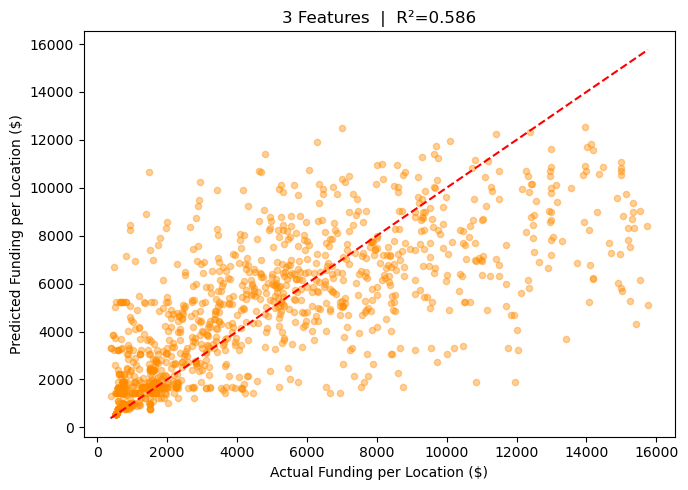

In [45]:
# Random Forest with miles_per_location + state_num_providers + total_fiber_miles
X_three = df[['miles_per_location', 'state_num_providers', 'total_fiber_miles']].fillna(0)
y_three = df['funding_per_location']

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_three, y_three, test_size=0.3, random_state=42)

rf_three = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf_three.fit(X_train_3, y_train_3)
y_pred_3 = rf_three.predict(X_test_3)

r2_3   = r2_score(y_test_3, y_pred_3)
rmse_3 = np.sqrt(mean_squared_error(y_test_3, y_pred_3))
mae_3  = mean_absolute_error(y_test_3, y_pred_3)
cv_3   = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_3 = cross_val_score(rf_three, X_three, y_three, cv=cv_3, scoring='r2')

print("=== Three Features: miles_per_location + state_num_providers + total_fiber_miles ===")
print(f"Test R²:               {r2_3:.3f}")
print(f"Test RMSE ($):         {rmse_3:,.0f}")
print(f"Test MAE ($):          {mae_3:,.0f}")
print(f"5-fold CV R²:          {cv_r2_3.mean():.3f} ± {cv_r2_3.std():.3f}")

print(f"\n--- Comparison ---")
print(f"8-feature R²: {r2:.3f}  |  3-feature R²: {r2_3:.3f}  |  2-feature R²: {r2_2:.3f}  |  1-feature R²: {r2_s:.3f}")

# Feature importance for the 3-feature model
print(f"\nFeature importances:")
for feat, imp in zip(['miles_per_location', 'state_num_providers', 'total_fiber_miles'], rf_three.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

# Predicted vs Actual
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(y_test_3, y_pred_3, alpha=0.4, s=20, color='darkorange')
lims = [min(y_test_3.min(), y_pred_3.min()), max(y_test_3.max(), y_pred_3.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual Funding per Location ($)')
ax.set_ylabel('Predicted Funding per Location ($)')
ax.set_title(f'3 Features  |  R²={r2_3:.3f}')
plt.tight_layout()
plt.show()

In [ ]:
# Model 4: 3 features + state_population
X_four = df[['miles_per_location', 'state_num_providers', 'total_fiber_miles', 'state_population']].fillna(0)
y_four = df['funding_per_location']

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_four, y_four, test_size=0.3, random_state=42)

rf_four = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf_four.fit(X_train_4, y_train_4)
y_pred_4 = rf_four.predict(X_test_4)

r2_4   = r2_score(y_test_4, y_pred_4)
rmse_4 = np.sqrt(mean_squared_error(y_test_4, y_pred_4))
mae_4  = mean_absolute_error(y_test_4, y_pred_4)
cv_4   = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_4 = cross_val_score(rf_four, X_four, y_four, cv=cv_4, scoring='r2')

print("=== Model 4: + state_population ===")
print(f"Test R²:               {r2_4:.3f}")
print(f"Test RMSE ($):         {rmse_4:,.0f}")
print(f"Test MAE ($):          {mae_4:,.0f}")
print(f"5-fold CV R²:          {cv_r2_4.mean():.3f} ± {cv_r2_4.std():.3f}")

print(f"\nFeature importances:")
for feat, imp in zip(X_four.columns, rf_four.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

print(f"\n--- Comparison ---")
print(f"8-feat: {r2:.3f} | 4-feat: {r2_4:.3f} | 3-feat: {r2_3:.3f} | 2-feat: {r2_2:.3f} | 1-feat: {r2_s:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(y_test_4, y_pred_4, alpha=0.4, s=20, color='mediumpurple')
lims = [min(y_test_4.min(), y_pred_4.min()), max(y_test_4.max(), y_pred_4.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual Funding per Location ($)')
ax.set_ylabel('Predicted Funding per Location ($)')
ax.set_title(f'Model 4 (+ state_population)  |  R²={r2_4:.3f}')
plt.tight_layout()
plt.show()

In [ ]:
# Model 5: 4 features + incumbent_democrat (governor party)
X_five = df[['miles_per_location', 'state_num_providers', 'total_fiber_miles',
             'state_population', 'incumbent_democrat']].fillna(0)
y_five = df['funding_per_location']

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_five, y_five, test_size=0.3, random_state=42)

rf_five = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf_five.fit(X_train_5, y_train_5)
y_pred_5 = rf_five.predict(X_test_5)

r2_5   = r2_score(y_test_5, y_pred_5)
rmse_5 = np.sqrt(mean_squared_error(y_test_5, y_pred_5))
mae_5  = mean_absolute_error(y_test_5, y_pred_5)
cv_5   = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_5 = cross_val_score(rf_five, X_five, y_five, cv=cv_5, scoring='r2')

print("=== Model 5: + incumbent_democrat (governor party) ===")
print(f"Test R²:               {r2_5:.3f}")
print(f"Test RMSE ($):         {rmse_5:,.0f}")
print(f"Test MAE ($):          {mae_5:,.0f}")
print(f"5-fold CV R²:          {cv_r2_5.mean():.3f} ± {cv_r2_5.std():.3f}")

print(f"\nFeature importances:")
for feat, imp in zip(X_five.columns, rf_five.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

print(f"\n--- Full Comparison ---")
print(f"8-feat: {r2:.3f} | 5-feat: {r2_5:.3f} | 4-feat: {r2_4:.3f} | 3-feat: {r2_3:.3f} | 2-feat: {r2_2:.3f} | 1-feat: {r2_s:.3f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.scatter(y_test_5, y_pred_5, alpha=0.4, s=20, color='crimson')
lims = [min(y_test_5.min(), y_pred_5.min()), max(y_test_5.max(), y_pred_5.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual Funding per Location ($)')
ax.set_ylabel('Predicted Funding per Location ($)')
ax.set_title(f'Model 5 (+ incumbent_democrat)  |  R²={r2_5:.3f}')
plt.tight_layout()
plt.show()

## Log-Transformed Target: Random Forest Models

In [ ]:
# Log-transformed target
y_log = np.log1p(df['funding_per_location'])

# --- 8-feature RF with log target ---
feature_cols_8 = ['technology', 'avg_latency', 'total_fiber_miles', 'miles_per_location',
                  'jobs_per_location', 'priority_broadband_project', 'project_type_code', 'state_num_providers']
X_log8 = df[feature_cols_8].fillna(0)

X_tr8, X_te8, y_tr8, y_te8 = train_test_split(X_log8, y_log, test_size=0.3, random_state=42)
rf_log8 = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf_log8.fit(X_tr8, y_tr8)
yp_log8 = rf_log8.predict(X_te8)

# Metrics in log space
r2_log8 = r2_score(y_te8, yp_log8)
cv_log8 = cross_val_score(rf_log8, X_log8, y_log, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')

# Convert back to real $ for comparable RMSE/MAE
yp_real8 = np.expm1(yp_log8)
yt_real8 = np.expm1(y_te8)
rmse_real8 = np.sqrt(mean_squared_error(yt_real8, yp_real8))
mae_real8 = mean_absolute_error(yt_real8, yp_real8)

print("=== 8-Feature RF — log(funding_per_location) ===")
print(f"Test R² (log space):   {r2_log8:.3f}")
print(f"5-fold CV R² (log):    {cv_log8.mean():.3f} ± {cv_log8.std():.3f}")
print(f"RMSE (real $):         {rmse_real8:,.0f}")
print(f"MAE (real $):          {mae_real8:,.0f}")

# --- 5-feature RF with log target ---
feature_cols_5 = ['miles_per_location', 'state_num_providers', 'total_fiber_miles',
                  'state_population', 'jobs_per_location']
X_log5 = df[feature_cols_5].fillna(0)

X_tr5, X_te5, y_tr5, y_te5 = train_test_split(X_log5, y_log, test_size=0.3, random_state=42)
rf_log5 = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf_log5.fit(X_tr5, y_tr5)
yp_log5 = rf_log5.predict(X_te5)

r2_log5 = r2_score(y_te5, yp_log5)
cv_log5 = cross_val_score(rf_log5, X_log5, y_log, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')

yp_real5 = np.expm1(yp_log5)
yt_real5 = np.expm1(y_te5)
rmse_real5 = np.sqrt(mean_squared_error(yt_real5, yp_real5))
mae_real5 = mean_absolute_error(yt_real5, yp_real5)

print(f"\n=== 5-Feature RF — log(funding_per_location) ===")
print(f"Features: {feature_cols_5}")
print(f"Test R² (log space):   {r2_log5:.3f}")
print(f"5-fold CV R² (log):    {cv_log5.mean():.3f} ± {cv_log5.std():.3f}")
print(f"RMSE (real $):         {rmse_real5:,.0f}")
print(f"MAE (real $):          {mae_real5:,.0f}")

# Feature importances
print(f"\n5-feature importances:")
for feat, imp in zip(feature_cols_5, rf_log5.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, yt, yp, title, r2val, color in [
    (axes[0], y_te8, yp_log8, '8-Feature RF (log target)', r2_log8, 'steelblue'),
    (axes[1], y_te5, yp_log5, '5-Feature RF (log target)', r2_log5, 'darkorange')]:
    ax.scatter(yt, yp, alpha=0.4, s=20, color=color)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('Actual log(Funding per Location)')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}  |  R²={r2val:.3f}')
plt.tight_layout()
plt.show()

## AIC Feature Selection

In [ ]:
# AIC-based feature selection across OLS, Ridge, Lasso, and Random Forest
# AIC = n*ln(RSS/n) + 2k  (lower is better)
import statsmodels.api as sm
from itertools import combinations
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

all_features = ['technology', 'avg_latency', 'total_fiber_miles', 'miles_per_location',
                'jobs_per_location', 'priority_broadband_project', 'project_type_code',
                'state_num_providers', 'state_population', 'incumbent_democrat']

# Ensure all features are numeric
for col in all_features:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

y_aic = df['funding_per_location'].astype(float).values
n = len(y_aic)

def calc_aic(y_true, y_pred, k):
    """AIC = n*ln(RSS/n) + 2*k"""
    rss = np.sum((y_true - y_pred) ** 2)
    return n * np.log(rss / n) + 2 * (k + 1)  # +1 for intercept

def run_aic_search(y_target, target_label):
    print(f"\n{'='*70}")
    print(f"AIC Feature Selection — {target_label}")
    print(f"{'='*70}")
    
    models = {
        'OLS': lambda: LinearRegression(),
        'Ridge': lambda: Ridge(alpha=1.0),
        'Lasso': lambda: Lasso(alpha=0.01, max_iter=10000),
        'Random Forest': lambda: RandomForestRegressor(n_estimators=100, min_samples_split=5, random_state=42, n_jobs=-1),
    }
    
    best_overall = {'AIC': np.inf}
    
    for model_name, model_fn in models.items():
        print(f"\n--- {model_name} ---")
        best_for_model = {'AIC': np.inf}
        
        for k in range(1, len(all_features) + 1):
            best_aic_k = np.inf
            best_combo_k = None
            best_r2_k = None
            
            for combo in combinations(all_features, k):
                X_combo = df[list(combo)].astype(float).fillna(0).values
                scaler = StandardScaler()
                X_sc = scaler.fit_transform(X_combo)
                
                model = model_fn()
                model.fit(X_sc, y_target)
                y_pred = model.predict(X_sc)
                
                aic = calc_aic(y_target, y_pred, k)
                if aic < best_aic_k:
                    best_aic_k = aic
                    best_combo_k = combo
                    best_r2_k = r2_score(y_target, y_pred)
            
            if k <= 5 or best_aic_k < best_for_model['AIC']:
                print(f"  k={k:2d}  AIC={best_aic_k:>12,.0f}  R²={best_r2_k:.4f}  {best_combo_k}")
            
            if best_aic_k < best_for_model['AIC']:
                best_for_model = {'model': model_name, 'k': k, 'AIC': best_aic_k, 
                                  'R²': best_r2_k, 'features': best_combo_k}
        
        print(f"  >> Best: k={best_for_model['k']}, AIC={best_for_model['AIC']:,.0f}")
        
        if best_for_model['AIC'] < best_overall['AIC']:
            best_overall = best_for_model
    
    print(f"\n{'='*70}")
    print(f"BEST OVERALL ({target_label}): {best_overall['model']}, k={best_overall['k']}")
    print(f"  AIC={best_overall['AIC']:,.0f}, R²={best_overall['R²']:.4f}")
    print(f"  Features: {best_overall['features']}")
    return best_overall

# Raw target
best_raw = run_aic_search(y_aic, 'funding_per_location (raw $)')

# Log target
y_aic_log = np.log1p(df['funding_per_location']).astype(float).values
best_log = run_aic_search(y_aic_log, 'log(funding_per_location)')

## Model Comparison: OLS, Ridge, Lasso vs Random Forest

In [ ]:
# Compare OLS, Ridge, Lasso, and RF using both raw and log targets
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Use the 8-feature set for apples-to-apples comparison
feat_compare = ['technology', 'avg_latency', 'total_fiber_miles', 'miles_per_location',
                'jobs_per_location', 'priority_broadband_project', 'project_type_code', 'state_num_providers']

X_all = df[feat_compare].fillna(0)
y_raw = df['funding_per_location']
y_log_all = np.log1p(y_raw)

# Scale features for Ridge/Lasso
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=feat_compare, index=X_all.index)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y, name, target_type='raw'):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    r2 = r2_score(y_te, y_pred)
    cv = cross_val_score(model, X, y, cv=kf, scoring='r2')
    
    if target_type == 'log':
        y_te_real = np.expm1(y_te)
        y_pred_real = np.expm1(y_pred)
    else:
        y_te_real = y_te
        y_pred_real = y_pred
    
    rmse = np.sqrt(mean_squared_error(y_te_real, y_pred_real))
    mae = mean_absolute_error(y_te_real, y_pred_real)
    
    return {'Model': name, 'Target': target_type, 'Test R²': r2, 'CV R²': f"{cv.mean():.3f}±{cv.std():.3f}",
            'RMSE ($)': rmse, 'MAE ($)': mae, 'model_obj': model}

# Run all models
all_results = []

# Raw target
all_results.append(evaluate_model(LinearRegression(), X_scaled, y_raw, 'OLS', 'raw'))
all_results.append(evaluate_model(Ridge(alpha=1.0), X_scaled, y_raw, 'Ridge', 'raw'))
all_results.append(evaluate_model(Lasso(alpha=1.0), X_scaled, y_raw, 'Lasso', 'raw'))
all_results.append(evaluate_model(RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1),
                                  X_all, y_raw, 'Random Forest', 'raw'))

# Log target
all_results.append(evaluate_model(LinearRegression(), X_scaled, y_log_all, 'OLS', 'log'))
all_results.append(evaluate_model(Ridge(alpha=1.0), X_scaled, y_log_all, 'Ridge', 'log'))
all_results.append(evaluate_model(Lasso(alpha=0.01), X_scaled, y_log_all, 'Lasso', 'log'))
all_results.append(evaluate_model(RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1),
                                  X_all, y_log_all, 'Random Forest', 'log'))

# Display results
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model_obj'} for r in all_results])
results_df['Test R²'] = results_df['Test R²'].round(3)
results_df['RMSE ($)'] = results_df['RMSE ($)'].apply(lambda x: f"{x:,.0f}")
results_df['MAE ($)'] = results_df['MAE ($)'].apply(lambda x: f"{x:,.0f}")
print("=== Model Comparison (8 features) ===")
print(results_df.to_string(index=False))

In [ ]:
# Coefficient comparison for linear models (log target, standardized features)
print("=== OLS Coefficients (log target, standardized) ===")
ols_model = [r for r in all_results if r['Model'] == 'OLS' and r['Target'] == 'log'][0]['model_obj']
ridge_model = [r for r in all_results if r['Model'] == 'Ridge' and r['Target'] == 'log'][0]['model_obj']
lasso_model = [r for r in all_results if r['Model'] == 'Lasso' and r['Target'] == 'log'][0]['model_obj']

coef_df = pd.DataFrame({
    'Feature': feat_compare,
    'OLS': ols_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
}).round(4)
print(coef_df.to_string(index=False))

# Lasso zeroed-out features
zeroed = coef_df[coef_df['Lasso'] == 0]['Feature'].tolist()
if zeroed:
    print(f"\nLasso dropped: {zeroed}")
else:
    print("\nLasso kept all features")

# Visual comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x = np.arange(len(feat_compare))
w = 0.25
ax.bar(x - w, coef_df['OLS'], w, label='OLS', color='steelblue')
ax.bar(x, coef_df['Ridge'], w, label='Ridge', color='coral')
ax.bar(x + w, coef_df['Lasso'], w, label='Lasso', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(feat_compare, rotation=45, ha='right')
ax.set_ylabel('Coefficient (standardized)')
ax.set_title('Linear Model Coefficients — log(funding_per_location)')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()